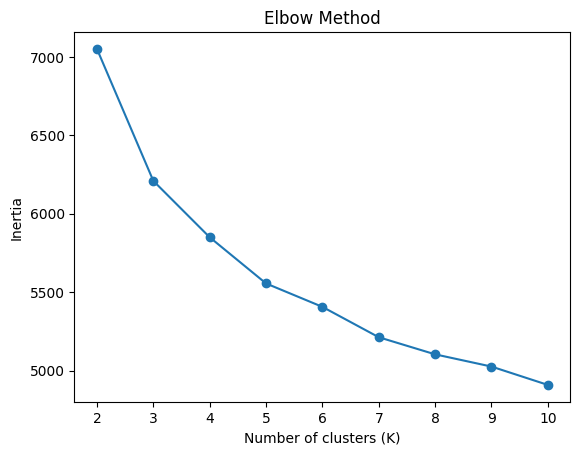

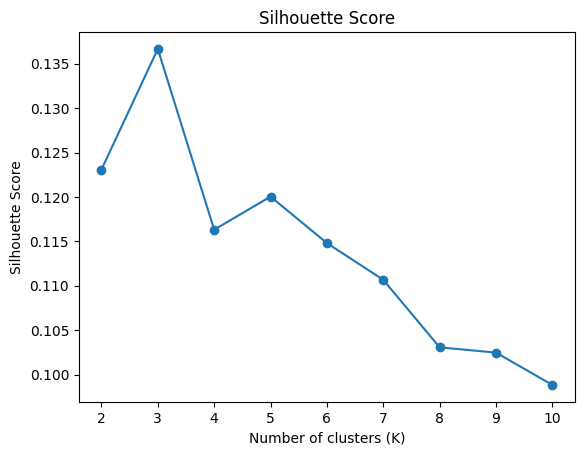

Clustering completed.


In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# =========================
# LOAD DATA
# =========================
df = pd.read_csv("encoded_for_kmeans_features_only.csv")

X = df.values  # numpy array

# =========================
# FIND OPTIMAL K (ELBOW + SILHOUETTE)
# =========================
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# =========================
# PLOT ELBOW
# =========================
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# =========================
# PLOT SILHOUETTE
# =========================
plt.figure()
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

# =========================
# CHOOSE BEST K (example: 4)
# =========================
best_k = 4

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

df["cluster"] = clusters

# Save results
df.to_csv("kmeans_results.csv", index=False)

print("Clustering completed.")